In [1]:
!pip install pandas
!pip install numpy

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

In [4]:
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [5]:
# Q1. Missing Data Identification Scenario:
 # The hospital suspects incomplete patient records.Task:
#Identify missing values in each column
#Calculate percentage of missing data
df.isnull().sum()


,0
Patient_ID,0
Age,600
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,593
Insurance_Coverage,0
Admission_Date,0


In [6]:
df.shape

(5100, 9)

In [11]:
(df.isnull().sum())/5100 * 100

,0
Patient_ID,0.000000
Age,11.764706
Gender,0.000000
City,0.000000
Diagnosis,0.000000
Hospital_Visits,0.000000
Treatment_Cost,11.627451
Insurance_Coverage,0.000000
Admission_Date,0.000000


In [8]:
len(df)

5100

In [12]:
#Q2. Handling Missing Age
#Scenario:
#Age is critical for medical analysis, but some values are missing.
#Task:
#Replace missing Age values with an appropriate method
#Justify your choice (mean/median)
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#first we have to check if there is any outliers because mean is affected by outliers and median dosent affect by any outliers
q1 = df["Age"].quantile(0.25)
q2 = df["Age"].quantile(0.50)
q3 = df["Age"].quantile(0.75)
iqr = q3 - q1
lb = q1-1.5*iqr
ub = q3 + 1.5*iqr
print(lb,ub)

-48.5 147.5


In [25]:
outliers = (df["Age"]< lb) | (df["Age"]> ub)

In [26]:
print(outliers)

0       False
1       False
2       False
3       False
4       False
        ...  
5095    False
5096    False
5097    False
5098    False
5099    False
Name: Age, Length: 5100, dtype: bool


In [27]:

outliers.sum()
# there is no outliers present so replace the missing values with mean

np.int64(0)

In [29]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [31]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,593
Insurance_Coverage,0
Admission_Date,0


(array([1836., 1758.,  863.,    0.,    0.,    0.,    0.,    0.,    0.,
          50.]),
 array([   526.        ,  20443.69653333,  40361.39306667,  60279.0896    ,
         80196.78613333, 100114.48266667, 120032.1792    , 139949.87573333,
        159867.57226667, 179785.2688    , 199702.96533333]),
 <BarContainer object of 10 artists>)

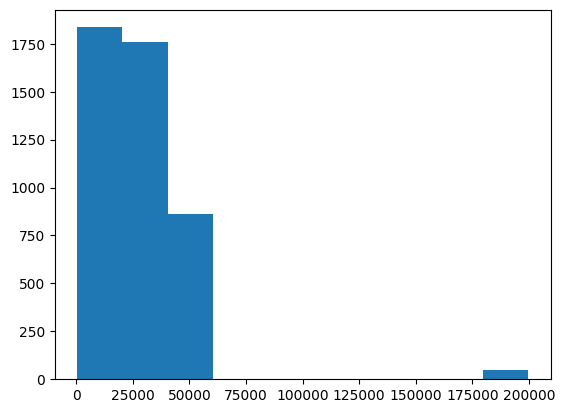

In [32]:
# Q3. Handling Missing Treatment Cost Scenario: Treatment cost is highly skewed due to expensive treatments.Task:
# Handle missing Treatment_Cost values
# Choose the correct imputation method and explain why
plt.hist(df["Treatment_Cost"])

In [33]:
df["Treatment_Cost"] = df["Treatment_Cost"].fillna(df["Treatment_Cost"].median())
#Checked the distribution of the Treatment_Cost column using a histogram.
# The data is right-skewed due to a few high treatment costs.
# Mean is affected by skewed data and outliers.
# Median is not affected by extreme values.
# Therefore, missing Treatment_Cost values were replaced using the median.

In [35]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,0
Insurance_Coverage,0
Admission_Date,0


In [ ]:
# Q4. Duplicate Patient Records Scenario: Some patient records were entered multiple times.Task:
#Identify duplicate rows
# Remove duplicates
# Compare dataset size before and after


In [37]:
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [38]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
5095,False
5096,True
5097,True
5098,True


In [39]:
df.duplicated().sum()

np.int64(99)

In [50]:
df = df.drop_duplicates()

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.shape
# The dataset size changed from 5100 × 9 to 5001 × 9 after removing duplicate records, indicating that 99 duplicate rows were removed while all 9 columns remained unchanged.

(5001, 9)

In [56]:
# Q5. Invalid Age Values (Data Quality Check) Scenario: Some patients have unrealistic age values (e.g., >100 or <0).Task:
#Detect such records
#Decide whether to remove or correct them
df[(df["Age"] > 100) | (df["Age"]<0)]

# Observation:
#No records with Age less than 0 or greater than 100 were found.
#Decision:
#Since there are no invalid age values, no correction or removal was required.
#Conclusion:
#The Age column passed the data quality check and contains only valid age values.

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date


In [53]:
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [55]:
df["Age"].dtypes

dtype('float64')

Q6. Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers

In [69]:
q1_TC = df["Treatment_Cost"].quantile(0.25)
q2_TC = df["Treatment_Cost"].quantile(0.50)
q3_TC = df["Treatment_Cost"].quantile(0.75)
iqr_TC = q3_TC-q1_TC
lb_TC = q1-1.5*iqr_TC
ub_TC = q3+1.5*iqr_TC
print(lb_TC,ub_TC)


-34139.0 34238.0


In [70]:
outliers_TC = df[(df["Treatment_Cost"] < lb_TC)| (df["Treatment_Cost"] > ub_TC)]

len(outliers_TC)


1441

Observation:

A total of 1441 outlier records were identified in the Treatment_Cost column using the IQR method.

Decision:

These outliers were not removed, as they may represent genuine high-cost medical treatments rather than data entry errors.

In [58]:
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile

In [73]:
df = df.copy()
lower_limit = df["Treatment_Cost"].quantile(0.05)
upper_limit = df["Treatment_Cost"].quantile(0.95)
df["Treatment_Cost"] = df["Treatment_Cost"].clip(
    lower=lower_limit,
    upper=upper_limit
)

In [74]:
df

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.000000,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.000000,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.000000,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.000000,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.000000,Female,Delhi,Asthma,1,9873.0,1,2023-06-20
...,...,...,...,...,...,...,...,...,...
4996,16135,49.597556,Female,Delhi,Hypertension,13,24797.0,1,2023-11-02
4997,15573,35.000000,Female,Delhi,COVID-19,19,3238.0,1,2023-12-02
4998,14131,60.000000,Female,Chennai,Hypertension,4,31337.0,0,2023-04-07
4999,19900,16.000000,Female,Chennai,Flu,16,39801.0,0,2023-08-04


Q8. Transformation

Scenario:
 Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution

In [75]:
import numpy as np
df["Log_Treatment_Cost"] = np.log(df["Treatment_Cost"])
df["Log_Treatment_Cost"] = np.log1p(df["Treatment_Cost"])


In [76]:
df

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date,Log_Treatment_Cost
0,17270,35.000000,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30,10.621596
1,10860,21.000000,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23,9.408781
2,15390,77.000000,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14,10.716349
3,15191,79.000000,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01,10.617491
4,15734,60.000000,Female,Delhi,Asthma,1,9873.0,1,2023-06-20,9.197660
...,...,...,...,...,...,...,...,...,...,...
4996,16135,49.597556,Female,Delhi,Hypertension,13,24797.0,1,2023-11-02,10.118518
4997,15573,35.000000,Female,Delhi,COVID-19,19,3238.0,1,2023-12-02,8.083020
4998,14131,60.000000,Female,Chennai,Hypertension,4,31337.0,0,2023-04-07,10.352587
4999,19900,16.000000,Female,Chennai,Flu,16,39801.0,0,2023-08-04,10.591672


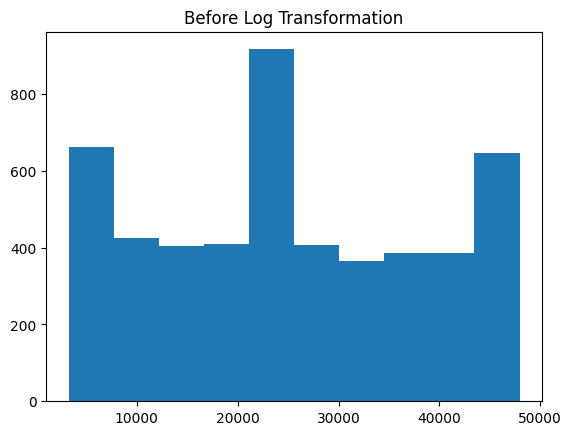

In [77]:
import matplotlib.pyplot as plt

plt.hist(df["Treatment_Cost"])
plt.title("Before Log Transformation")
plt.show()

Observation:

Right-skewed distribution.
Long right tail.
Extreme values present.

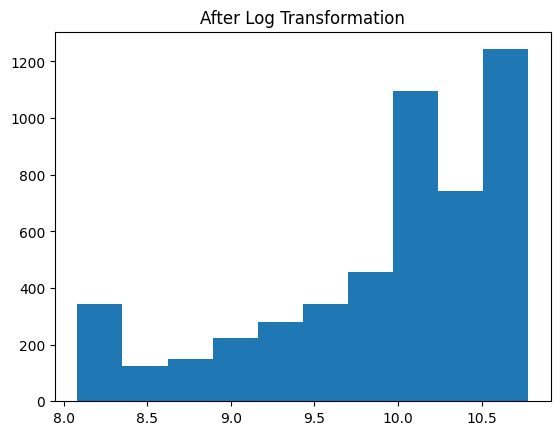

In [78]:
plt.hist(df["Log_Treatment_Cost"])
plt.title("After Log Transformation")
plt.show()

Observation:

Distribution becomes more symmetric.
Skewness is reduced.
Extreme values have less influence.

Q9. Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice

In [79]:
df["Admission_Date"].isnull().sum()

np.int64(0)

In [80]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

In [84]:
import pandas as pd

df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

df = df.sort_values(by="Admission_Date")

df["Admission_Date"] = df["Admission_Date"].ffill()

Action Taken:

Converted Admission_Date to datetime format.
Sorted the dataset by Admission_Date.
Applied Forward Fill (ffill) to replace missing dates.

Justification:

Forward Fill uses the previous valid date, preserving the logical time sequence.
It avoids using future information and is appropriate for sequential time-based data.

In [85]:
df

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date,Log_Treatment_Cost
2932,19591,91.000000,Male,Chennai,Asthma,3,32149.0,0,2023-01-01,10.378168
4617,10896,88.000000,Female,Chennai,COVID-19,3,47948.0,1,2023-01-01,10.777893
2642,19262,49.597556,Female,Hyderabad,Asthma,9,24797.0,0,2023-01-01,10.118518
4837,12843,89.000000,Female,Bangalore,COVID-19,14,46469.0,1,2023-01-01,10.746562
2702,17230,41.000000,Male,Bangalore,Hypertension,18,12398.0,0,2023-01-01,9.425371
...,...,...,...,...,...,...,...,...,...,...
1942,12852,70.000000,Female,Mumbai,COVID-19,10,39549.0,0,2023-12-31,10.585321
1723,13432,49.597556,Male,Bangalore,Hypertension,9,24797.0,1,2023-12-31,10.118518
2593,11125,32.000000,Female,Mumbai,Flu,16,42518.0,0,2023-12-31,10.657706
3013,13630,73.000000,Male,Bangalore,Diabetes,3,3238.0,0,2023-12-31,8.083020
